/tmp/ipykernel_1826958/609714267.py:43: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)


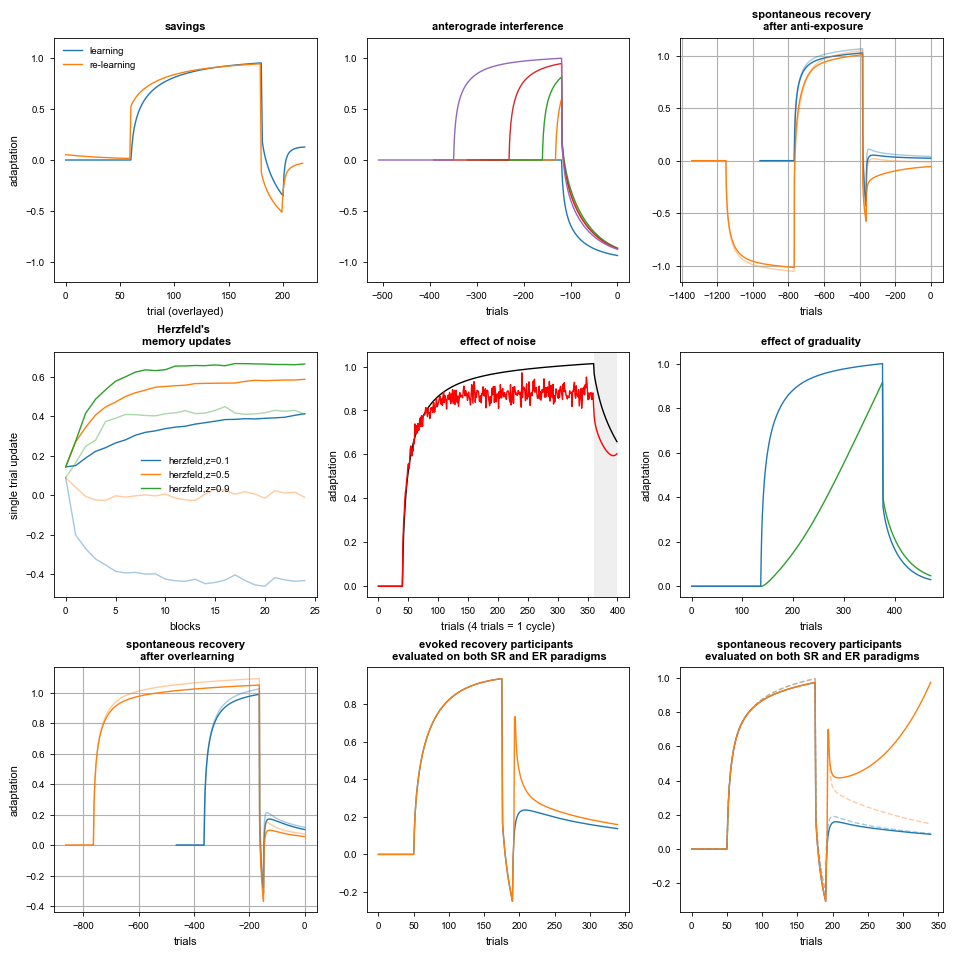

('/scratch/ar2342/one_more_dir/contextual_frogs/figs/repretoirePlotMarch19.pdf',
 '/scratch/ar2342/one_more_dir/contextual_frogs/figs/repretoirePlot.svg')

In [65]:
# Retry with corrected parsing of family/suffix from keys (handles 'dual_rate_*').

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Circle, FancyArrow

from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle

from plt_utils import parse_herzfeld_data
base_dir  = os.getcwd()+"/figs/"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
    "axes.linewidth": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.frameon": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

def mm_to_in(mm): return mm/25.4
W = mm_to_in(2*120)
H = W  #
fig, axes = plt.subplots(3, 3, figsize=(W, H), constrained_layout=True,)
# fig, axes = plt.subplots(4, 4, figsize=(W, H), constrained_layout=True)
# plt.subplots_adjust(wspace=0.02, hspace=0.02, left=1)
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
# families = {"coin": "///", "dual_rate": "xx", "clnn": "++"}
# families = {"coin": "", "dual_rate": "xx", "clnn": "++"}
# suffix_colors = {"a": "#254EDB", "x": "#E59F00", "u": "#F6C453"}
# families = {"coin": "#254EDB", "dual_rate": "#9B28AA", "clnn": "#F58529"}
# suffixes = {"a": "", "x": "//", "u": "xx"}
# sfx_for_legend = {"a": "output\n or input", "x": "internal\n node", "u": "efference\n copy"}
# fam_for_legend = {"coin": "COIN", "dual_rate": "dual-rate", "clnn": "CLNN"}
def subgroup(idx):
    return "SR" if idx < 8 else "ER"
bg_color = {"SR": "#F7FBFF", "ER": "#FFF8F0"}

# xpos = np.arange(len(order))
bar_width = 0.9
edge_width = 0.6
highlight_width = 2.4

YRANGE = 300          

# ids = [8,12]

with open('/homes/ar2342/one_more_dir/contextual_frogs/aux_part2/dataMar18.pkl', 'rb') as f:
    main_results = pickle.load(f)

with open('/homes/ar2342/one_more_dir/contextual_frogs/aux_part2/dataMar18_Inj0.pkl', 'rb') as f:
    secondary_results = pickle.load(f)

pooling_fun = np.mean
plt.subplot(3,3,1)
plt.plot(pooling_fun(main_results['savings'][:221], axis=1) , label='learning')
plt.plot(pooling_fun(main_results['savings'][221:], axis=1), label='re-learning')
# for subj in range(subjs):
    # plt.plot(ooo['savings'][221:, subj], color='gray', alpha=0.3)
plt.title('savings', fontweight='bold')
plt.xlabel('trial (overlayed)')
plt.ylabel('adaptation')
plt.ylim([-1.2, 1.2])
plt.legend()

plt.subplot(3,3,2)

ant_list = [f'AB{i}' for i in range(0,5)]
plt.title('anterograde interference', fontweight='bold')
plt.xlabel('trials')

for ant in ant_list:
    x_data = np.arange(len(main_results[ant].mean(axis=1)))
    plt.plot(x_data-np.max(x_data),pooling_fun(main_results[ant], axis=1))
plt.ylim([-1.2, 1.2])


plt.subplot(3,3,3)
for ii,these_results in enumerate([main_results, secondary_results]):
    plt.title('spontaneous recovery\n after anti-exposure', fontweight='bold')
    plt.xlabel('trials')

    x1 = np.arange(these_results['pretrained_sr_baseline'].shape[0])
    x1 = x1 - np.max(x1)
    x2 = np.arange(these_results['pretrained_sr'].shape[0])
    x2 = x2 - np.max(x2)
    plt.plot(x1, pooling_fun(these_results['pretrained_sr_baseline'], axis=1),alpha=1 if ii==0 else 0.4, color='tab:blue')
    plt.plot(x2, pooling_fun(these_results['pretrained_sr'], axis=1),alpha=1 if ii==0 else 0.4, color='tab:orange')
plt.grid()


plt.subplot(3,3,4)
plt.title("Herzfeld's \n memory updates", fontweight='bold')
plt.xlabel('blocks')
plt.ylabel('single trial update')
colors = ['tab:blue', 'tab:orange', 'tab:green']
for ii,these_results in enumerate([main_results, secondary_results]):
    data = parse_herzfeld_data(these_results)
    for jj,(key,deltas) in enumerate(data.items()):
        plt.plot( pooling_fun(deltas, axis=0), alpha=1 if ii==0 else 0.4, label=key if ii==0 else None, color = colors[jj])
plt.legend()


plt.subplot(3,3,5)
kk = 15/14
plt.plot(kk*main_results['albert_block_0'].mean(axis=1), label='noiseless albert block', color='black')

noisy_trials = [main_results[f'albert_block_{ii}'].mean(axis=1) for ii in range(1,100)]
plt.plot(kk*np.mean(noisy_trials, axis=0), label='noisy albert blocks mean', color='red')
plt.axvspan(360, 400, facecolor='gray',  alpha=0.12, zorder=0)
plt.title('effect of noise', fontweight='bold')
plt.xlabel('trials (4 trials = 1 cycle)')
plt.ylabel('adaptation')

plt.subplot(3,3,6)

plt.plot(np.mean(main_results['frogs'], axis=1), label='gradual', color='tab:green')
plt.plot(np.mean(main_results['anti_frogs'], axis=1), label='abrupt', color='tab:blue')
plt.title('effect of graduality', fontweight='bold')
plt.xlabel('trials')
plt.ylabel('adaptation')
# plt.grid()

#     i = ids[s]


#     ax = axes[s, 0]
#     # ax.set_facecolor(bg_color[subgroup(s)])
#     pert = build_piecewise_ys(paradigm='er' if s==0 else 'sr')
#     x_pert = np.arange(len(pert))
#     ax.plot(x_pert,pert, label='experiment', marker='o', color='black', alpha=1,  markersize=1.5,linewidth=1)
#     ax.plot(x_pert[np.isnan(pert)],np.isnan(pert)[np.isnan(pert)]*0,':', label='experiment', marker=None, color='black', alpha=0.4,  markersize=1.5,linewidth=5.)
#     # ccc = FancyArrow(240,1, -30, -0, width=0.1, length_includes_head=True, head_width=0.2, head_length=10, color='red', alpha=0.5)
#     if s==0:
#         ax.add_patch(ccc)
#     # ax.plot(-prior_a, label='prior', linestyle='-', color='tab:orange', alpha=0.4, linewidth=2)
#     ax.set_ylim(-1.2, 1.2)
#     if s==0:
#         ax.set_yticks([])      # no ticks
#         ax.set_xticks([])      # no ticks 
#     else:
#         ax.set_xlabel("trials")
#         ax.set_ylabel("perturbation / adaptation")
#         ax.text(10.05, -1.0, 'force field')
#         ax.text(210, -1.0, 'channel')

#     if s==0: ax.title.set_text('perturbation')
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     def organize_bg(ax):
#         ax.axvspan(0, 190, facecolor='green', alpha=0.12, zorder=0)
#         ax.axvspan(190, 340, facecolor='gray',  alpha=0.12, zorder=0)
#         ax.set_xlim(0,340)
#     organize_bg(ax)
#     ax = axes[s, 1]
#     # ax.set_facecolor(bg_color[subgroup(s)])
#     ax.plot(-exp_data, label='experiment', marker='o', color='black', alpha=0.7,  markersize=1.5,linewidth=0.001)
#     ax.plot(-prior_a, label='model mean', linestyle='-', color='tab:orange', alpha=0.4, linewidth=2)
#     # if s==1: ax.legend(loc='lower left', fontsize=7, framealpha=0.5)
#     ax.set_ylim(-1.2, 1.2)
#     if True:
#         ax.set_yticks([])      # no ticks
#         ax.set_xticks([])      # no ticks 
#     else:
#         ax.set_xlabel("trials")
#         ax.set_ylabel("perturbation / adaptation")

#     if s==0: ax.title.set_text('adaptation')

#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     organize_bg(ax)
    
#     ax = axes[s, 2]
#     ax.plot(-prior_a0123[:,0], label='prior', linestyle='-', color='tab:blue',linewidth=2)
#     ax.plot(-prior_a0123[:,1:], label='prior', linestyle='-', color='tab:blue', alpha=0.4, linewidth=1)
#     #remove all the axes decorations
#     ax.set_yticks([])      # no ticks
#     ax.set_xticks([])      # no ticks
#     ax.set_ylim(-1.2, 1.2)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     if s==0: ax.title.set_text('samples from model')
#     organize_bg(ax)



#     ax.set_xticks([]); 
#     ax.set_yticklabels([])

#     if not c==0:
#         ax.set_yticks([])      # no ticks

plt.subplot(3,3,7)
for ii,these_results in enumerate([main_results, secondary_results]):
    plt.title('spontaneous recovery\n after overlearning', fontweight='bold')
    x1 = np.arange(these_results['overlearning_baseline'].shape[0])
    x1 = x1 - np.max(x1)
    x2 = np.arange(these_results['overlearning'].shape[0])
    x2 = x2 - np.max(x2)
    plt.plot(x1, pooling_fun(these_results['overlearning_baseline'], axis=1),alpha=1 if ii==0 else 0.4, color='tab:blue')
    plt.plot(x2, pooling_fun(these_results['overlearning'], axis=1),alpha=1 if ii==0 else 0.4, color='tab:orange')
    plt.xlabel('trials')
    plt.ylabel('adaptation')
plt.grid()

plt.subplot(3,3,8)

plt.plot(pooling_fun(main_results['spontaneous'][:,:8], axis=1) , label='learning')
plt.plot(pooling_fun(main_results['evoked'][:,:8], axis=1) , label='learning')
plt.title('evoked recovery participants \n evaluated on both SR and ER paradigms', fontweight='bold')
plt.xlabel('trials')

plt.subplot(3,3,9)

plt.plot(pooling_fun(main_results['spontaneous'][:,[8,9,10,11,12,13,15]], axis=1) ,'--', label='learning', color='tab:blue', alpha=0.4)
plt.plot(pooling_fun(main_results['evoked'][:,[8,9,10,11,12,13,15]], axis=1) , '--', label='learning', color='tab:orange', alpha=0.4)

plt.plot(pooling_fun(main_results['spontaneous'][:,8:], axis=1) ,  label='learning', color='tab:blue')
plt.plot(pooling_fun(main_results['evoked'][:,8:], axis=1) , label='learning', color='tab:orange')
plt.xlabel('trials')

plt.title('spontaneous recovery participants \n evaluated on both SR and ER paradigms', fontweight='bold')

pdf_path = os.path.join(base_dir, "repretoirePlotMarch19.pdf")
svg_path = os.path.join(base_dir, "repretoirePlot.svg")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight", transparent=True)
# fig.savefig(svg_path, format="svg", bbox_inches="tight", transparent=True)
plt.show()

pdf_path, svg_path


In [66]:
np.shape(deltas)

(5, 25)